In [ ]:
# Importing the necessary libraries
import json
import os
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")


'4'

In [ ]:
# Upload Dataset Files
uploaded = files.upload()


Saving fraudTrain.csv to fraudTrain.csv


In [ ]:
# Upload Dataset Files
uploaded = files.upload()

Saving fraudTest.csv to fraudTest.csv


In [ ]:
# File Paths And Feature Configuration
BASE_DIR = Path(".")
TRAIN_DATA_PATH = BASE_DIR / "fraudTrain.csv"
TEST_DATA_PATH = BASE_DIR / "fraudTest.csv"
MODEL_PATH = BASE_DIR / "fraud_model.pkl"
ENCODERS_PATH = BASE_DIR / "encoders.pkl"
METRICS_PATH = BASE_DIR / "training_metrics.json"
ALGORITHM_COMPARISON_PATH = BASE_DIR / "algorithm_comparison_metrics.json"
TEST_METRICS_PATH = BASE_DIR / "test_metrics.json"

FEATURE_COLUMNS = [
    "amt",
    "category",
    "gender",
    "city_pop",
    "state",
    "job",
    "city",
    "age",
    "hour",
    "distance_km",
]

NUMERIC_FEATURES = ["amt", "city_pop", "age", "hour", "distance_km"]
CATEGORICAL_FEATURES = ["category", "gender", "state", "job", "city"]


In [ ]:
# Distance Feature Calculation
def haversine_distance(lat1, lon1, lat2, lon2) -> np.ndarray:
    radius_km = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return radius_km * c


In [ ]:
# Calculate Evaluation Metrics
def calculate_metrics(
    model_name: str,
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
) -> dict:
    return {
        "model": model_name,
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1_score": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 4),
        "report": classification_report(
            y_true,
            y_pred,
            output_dict=True,
            zero_division=0,
        ),
    }


In [ ]:
# Convert K Means Clusters Into Fraud Labels
def get_kmeans_predictions(
    model: KMeans,
    X_train_dense: np.ndarray,
    y_train_data: pd.Series,
    X_test_dense: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    train_clusters = model.predict(X_train_dense)
    cluster_label_map = {}

    for cluster_id in range(model.n_clusters):
        cluster_targets = y_train_data[train_clusters == cluster_id]
        if len(cluster_targets) == 0:
            cluster_label_map[cluster_id] = 0
        else:
            cluster_label_map[cluster_id] = int(cluster_targets.mode().iloc[0])

    test_clusters = model.predict(X_test_dense)
    y_pred = np.array([cluster_label_map[cluster_id] for cluster_id in test_clusters])

    distances = model.transform(X_test_dense)
    nearest_distance = distances.min(axis=1)
    normalized_distance = nearest_distance / (nearest_distance.max() + 1e-9)
    fraud_cluster_flags = np.array(
        [cluster_label_map[cluster_id] for cluster_id in test_clusters],
        dtype=float,
    )
    y_prob = np.where(
        fraud_cluster_flags == 1.0,
        1.0 - normalized_distance,
        normalized_distance,
    )
    y_prob = np.clip(y_prob, 0.0, 1.0)

    return y_pred, y_prob


In [ ]:
# Create Model Selection Summary
###
def build_model_selection_summary(results: list[dict]) -> str:
    if not results:
        return "No comparison results were generated."

    best_model = results[0]
    return (
        f"{best_model['model']} was selected because it gave the best overall balance of "
        f"ROC-AUC ({best_model['roc_auc']}), recall ({best_model['recall']}), and F1-score "
        f"({best_model['f1_score']}) on the fraud detection dataset. Fraud detection gives high "
        "importance to recall because missing a fraudulent transaction is usually more costly "
        "than incorrectly flagging a normal transaction."
    )


In [ ]:
# Load Raw Training Dataset
train_df_raw = pd.read_csv(TRAIN_DATA_PATH)

print("Dataset loaded from:", TRAIN_DATA_PATH)
print("Dataset shape:", train_df_raw.shape)
train_df_raw.head()


Dataset loaded from: fraudTrain.csv
Dataset shape: (1296675, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
# Preprocessing Data And Engineering Features
train_df_raw["trans_date_trans_time"] = pd.to_datetime(
    train_df_raw["trans_date_trans_time"], errors="coerce"
)
train_df_raw["dob"] = pd.to_datetime(train_df_raw["dob"], errors="coerce")

age_days = (train_df_raw["trans_date_trans_time"] - train_df_raw["dob"]).dt.days
train_df_raw["age"] = (age_days / 365.25).clip(lower=0)
train_df_raw["hour"] = train_df_raw["trans_date_trans_time"].dt.hour
train_df_raw["distance_km"] = haversine_distance(
    train_df_raw["lat"],
    train_df_raw["long"],
    train_df_raw["merch_lat"],
    train_df_raw["merch_long"],
)

model_df = train_df_raw[FEATURE_COLUMNS + ["is_fraud"]].dropna(subset=["is_fraud"]).copy()
model_df.head()


,amt,category,gender,city_pop,state,job,city,age,hour,distance_km,is_fraud
0,4.97,misc_net,F,3495,NC,"Psychologist, counselling",Moravian Falls,30.814511,0,78.597568,0
1,107.23,grocery_pos,F,149,WA,Special educational needs teacher,Orient,40.531143,0,30.212176,0
2,220.11,entertainment,M,4154,ID,Nature conservation officer,Malad City,56.950034,0,108.206083,0
3,45.00,gas_transport,M,1939,MT,Patent attorney,Boulder,51.969884,0,95.673231,0
4,41.96,misc_pos,M,99,VA,Dance movement psychotherapist,Doe Hill,32.763860,0,77.556744,0


In [ ]:
# Target Class Distribution Check
print(model_df["is_fraud"].value_counts())
print(model_df["is_fraud"].value_counts(normalize=True))


is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


In [ ]:
# Split Data Into Training And Testing Sets
X = model_df[FEATURE_COLUMNS]
y = model_df["is_fraud"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (1037340, 10)
Testing data shape: (259335, 10)


In [ ]:
# Build The Preprocessing Pipeline
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float32,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    sparse_threshold=1.0,
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (1037340, 1460)
Processed testing shape: (259335, 1460)


In [ ]:
# Compare Multiple Machine Learning Algorithms
comparison_train_size = min(X_train_processed.shape[0], 30000)
comparison_test_size = min(X_test_processed.shape[0], 10000)

if comparison_train_size < X_train_processed.shape[0]:
    _, X_train_compare, _, y_train_compare = train_test_split(
        X_train_processed,
        y_train,
        test_size=comparison_train_size,
        random_state=42,
        stratify=y_train,
    )
else:
    X_train_compare = X_train_processed
    y_train_compare = y_train.copy()

if comparison_test_size < X_test_processed.shape[0]:
    _, X_test_compare, _, y_test_compare = train_test_split(
        X_test_processed,
        y_test,
        test_size=comparison_test_size,
        random_state=42,
        stratify=y_test,
    )
else:
    X_test_compare = X_test_processed
    y_test_compare = y_test.copy()

y_train_compare = y_train_compare.reset_index(drop=True)
y_test_compare = y_test_compare.reset_index(drop=True)

comparison_fraud_count = max(int(y_train_compare.sum()), 1)
comparison_normal_count = max(int((y_train_compare == 0).sum()), 1)
comparison_scale_pos_weight = comparison_normal_count / comparison_fraud_count

X_train_compare_dense = X_train_compare.toarray()
X_test_compare_dense = X_test_compare.toarray()

comparison_results = []


In [ ]:
# K Means Clustering
kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_model.fit(X_train_compare_dense)
kmeans_pred, kmeans_prob = get_kmeans_predictions(
    kmeans_model,
    X_train_compare_dense,
    y_train_compare,
    X_test_compare_dense,
)
kmeans_metrics = calculate_metrics("K Means Clustering", y_test_compare, kmeans_pred, kmeans_prob)
comparison_results.append(kmeans_metrics)
kmeans_metrics


{'model': 'K Means Clustering',
 'accuracy': 0.9942,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'roc_auc': 0.8502,
 'report': {'0': {'precision': 0.9942,
   'recall': 1.0,
   'f1-score': 0.9970915655400662,
   'support': 9942.0},
  '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 58.0},
  'accuracy': 0.9942,
  'macro avg': {'precision': 0.4971,
   'recall': 0.5,
   'f1-score': 0.4985457827700331,
   'support': 10000.0},
  'weighted avg': {'precision': 0.98843364,
   'recall': 0.9942,
   'f1-score': 0.9913084344599338,
   'support': 10000.0}}}

In [ ]:
# K Nearest Neighbour
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_compare, y_train_compare)
knn_pred = knn_model.predict(X_test_compare)
knn_prob = knn_model.predict_proba(X_test_compare)[:, 1]
knn_metrics = calculate_metrics("K Nearest Neighbour", y_test_compare, knn_pred, knn_prob)
comparison_results.append(knn_metrics)
knn_metrics


{'model': 'K Nearest Neighbour',
 'accuracy': 0.9962,
 'precision': 0.8846,
 'recall': 0.3966,
 'f1_score': 0.5476,
 'roc_auc': 0.7902,
 'report': {'0': {'precision': 0.9964908762783237,
   'recall': 0.9996982498491249,
   'f1-score': 0.9980919863426391,
   'support': 9942.0},
  '1': {'precision': 0.8846153846153846,
   'recall': 0.39655172413793105,
   'f1-score': 0.5476190476190477,
   'support': 58.0},
  'accuracy': 0.9962,
  'macro avg': {'precision': 0.9405531304468542,
   'recall': 0.698124986993528,
   'f1-score': 0.7728555169808433,
   'support': 10000.0},
  'weighted avg': {'precision': 0.9958419984266785,
   'recall': 0.9962,
   'f1-score': 0.9954792432980423,
   'support': 10000.0}}}

In [ ]:
# Support Vector Machine
svm_train_size = min(len(y_train_compare), 3000)
svm_test_size = min(len(y_test_compare), 1000)

X_svm_train = X_train_compare_dense[:svm_train_size]
y_svm_train = y_train_compare[:svm_train_size]

X_svm_test = X_test_compare_dense[:svm_test_size]
y_svm_test = y_test_compare[:svm_test_size]

svm_model = SVC(
    kernel="linear",
    probability=True,
    class_weight="balanced",
    random_state=42,
)

svm_model.fit(X_svm_train, y_svm_train)
svm_pred = svm_model.predict(X_svm_test)
svm_prob = svm_model.predict_proba(X_svm_test)[:, 1]

svm_metrics = calculate_metrics(
    "Support Vector Machine",
    y_svm_test,
    svm_pred,
    svm_prob,
)
comparison_results.append(svm_metrics)
svm_metrics


{'model': 'Support Vector Machine',
 'accuracy': 0.991,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'roc_auc': 0.6788,
 'report': {'0': {'precision': 0.9929859719438878,
   'recall': 0.9979859013091642,
   'f1-score': 0.9954796584630838,
   'support': 993.0},
  '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 7.0},
  'accuracy': 0.991,
  'macro avg': {'precision': 0.4964929859719439,
   'recall': 0.4989929506545821,
   'f1-score': 0.4977398292315419,
   'support': 1000.0},
  'weighted avg': {'precision': 0.9860350701402806,
   'recall': 0.991,
   'f1-score': 0.9885113008538423,
   'support': 1000.0}}}

In [ ]:
# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    n_jobs=4,
    random_state=42,
)
logistic_model.fit(X_train_compare, y_train_compare)
logistic_pred = logistic_model.predict(X_test_compare)
logistic_prob = logistic_model.predict_proba(X_test_compare)[:, 1]
logistic_metrics = calculate_metrics("Logistic Regression", y_test_compare, logistic_pred, logistic_prob)
comparison_results.append(logistic_metrics)
logistic_metrics


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'model': 'Logistic Regression',
 'accuracy': 0.9608,
 'precision': 0.0887,
 'recall': 0.6207,
 'f1_score': 0.1552,
 'roc_auc': 0.922,
 'report': {'0': {'precision': 0.9977069001459246,
   'recall': 0.9627841480587407,
   'f1-score': 0.9799344799344799,
   'support': 9942.0},
  '1': {'precision': 0.08866995073891626,
   'recall': 0.6206896551724138,
   'f1-score': 0.15517241379310345,
   'support': 58.0},
  'accuracy': 0.9608,
  'macro avg': {'precision': 0.5431884254424204,
   'recall': 0.7917369016155773,
   'f1-score': 0.5675534468637917,
   'support': 10000.0},
  'weighted avg': {'precision': 0.9924344858393639,
   'recall': 0.9608,
   'f1-score': 0.9751508599508599,
   'support': 10000.0}}}

In [ ]:
# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=4,
)
random_forest_model.fit(X_train_compare, y_train_compare)
random_forest_pred = random_forest_model.predict(X_test_compare)
random_forest_prob = random_forest_model.predict_proba(X_test_compare)[:, 1]
random_forest_metrics = calculate_metrics("Random Forest", y_test_compare, random_forest_pred, random_forest_prob)
comparison_results.append(random_forest_metrics)
random_forest_metrics


{'model': 'Random Forest',
 'accuracy': 0.986,
 'precision': 0.2697,
 'recall': 0.8276,
 'f1_score': 0.4068,
 'roc_auc': 0.9783,
 'report': {'0': {'precision': 0.9989818774180411,
   'recall': 0.9869241601287467,
   'f1-score': 0.992916413681441,
   'support': 9942.0},
  '1': {'precision': 0.2696629213483146,
   'recall': 0.8275862068965517,
   'f1-score': 0.4067796610169492,
   'support': 58.0},
  'accuracy': 0.986,
  'macro avg': {'precision': 0.6343223993831779,
   'recall': 0.9072551835126492,
   'f1-score': 0.6998480373491951,
   'support': 10000.0},
  'weighted avg': {'precision': 0.9947518274728367,
   'recall': 0.986,
   'f1-score': 0.9895168205159871,
   'support': 10000.0}}}

In [ ]:
# XGBoost Comparison
xgboost_compare_model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=comparison_scale_pos_weight,
    random_state=42,
    n_jobs=4,
)
xgboost_compare_model.fit(X_train_compare, y_train_compare)
xgboost_compare_pred = xgboost_compare_model.predict(X_test_compare)
xgboost_compare_prob = xgboost_compare_model.predict_proba(X_test_compare)[:, 1]
xgboost_compare_metrics = calculate_metrics("XGBoost", y_test_compare, xgboost_compare_pred, xgboost_compare_prob)
comparison_results.append(xgboost_compare_metrics)
xgboost_compare_metrics


{'model': 'XGBoost',
 'accuracy': 0.9984,
 'precision': 0.85,
 'recall': 0.8793,
 'f1_score': 0.8644,
 'roc_auc': 0.9956,
 'report': {'0': {'precision': 0.9992957746478873,
   'recall': 0.9990947495473748,
   'f1-score': 0.9991952519867217,
   'support': 9942.0},
  '1': {'precision': 0.85,
   'recall': 0.8793103448275862,
   'f1-score': 0.864406779661017,
   'support': 58.0},
  'accuracy': 0.9984,
  'macro avg': {'precision': 0.9246478873239437,
   'recall': 0.9392025471874805,
   'f1-score': 0.9318010158238693,
   'support': 10000.0},
  'weighted avg': {'precision': 0.9984298591549295,
   'recall': 0.9984,
   'f1-score': 0.9984134788472325,
   'support': 10000.0}}}

In [ ]:
# Save Algorithm Comparison Metrics
comparison_results.sort(
    key=lambda item: (item["roc_auc"], item["recall"], item["f1_score"]),
    reverse=True,
)

comparison_payload = {
    "dataset": TRAIN_DATA_PATH.name,
    "generated_at": datetime.now().isoformat(),
    "comparison_train_sample_size": int(X_train_compare.shape[0]),
    "comparison_test_sample_size": int(X_test_compare.shape[0]),
    "selected_model": comparison_results[0]["model"] if comparison_results else None,
    "selection_reason": build_model_selection_summary(comparison_results),
    "results": comparison_results,
}

ALGORITHM_COMPARISON_PATH.write_text(
    json.dumps(comparison_payload, indent=2),
    encoding="utf-8",
)

comparison_payload


{'dataset': 'fraudTrain.csv',
 'generated_at': '2026-04-09T19:35:24.237059',
 'comparison_train_sample_size': 30000,
 'comparison_test_sample_size': 10000,
 'selected_model': 'XGBoost',
 'selection_reason': 'XGBoost was selected because it gave the best overall balance of ROC-AUC (0.9956), recall (0.8793), and F1-score (0.8644) on the fraud detection dataset. Fraud detection gives high importance to recall because missing a fraudulent transaction is usually more costly than incorrectly flagging a normal transaction.',
 'results': [{'model': 'XGBoost',
   'accuracy': 0.9984,
   'precision': 0.85,
   'recall': 0.8793,
   'f1_score': 0.8644,
   'roc_auc': 0.9956,
   'report': {'0': {'precision': 0.9992957746478873,
     'recall': 0.9990947495473748,
     'f1-score': 0.9991952519867217,
     'support': 9942.0},
    '1': {'precision': 0.85,
     'recall': 0.8793103448275862,
     'f1-score': 0.864406779661017,
     'support': 58.0},
    'accuracy': 0.9984,
    'macro avg': {'precision': 0.9

In [ ]:
# Visual Comparison Table
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame(comparison_results)[
    ["model", "accuracy", "precision", "recall", "f1_score", "roc_auc"]
]

comparison_df


,model,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,0.9984,0.8500,0.8793,0.8644,0.9956
1,Random Forest,0.9860,0.2697,0.8276,0.4068,0.9783
2,Logistic Regression,0.9608,0.0887,0.6207,0.1552,0.9220
3,K Means Clustering,0.9942,0.0000,0.0000,0.0000,0.8502
4,K Nearest Neighbour,0.9962,0.8846,0.3966,0.5476,0.7902
5,Support Vector Machine,0.9910,0.0000,0.0000,0.0000,0.6788


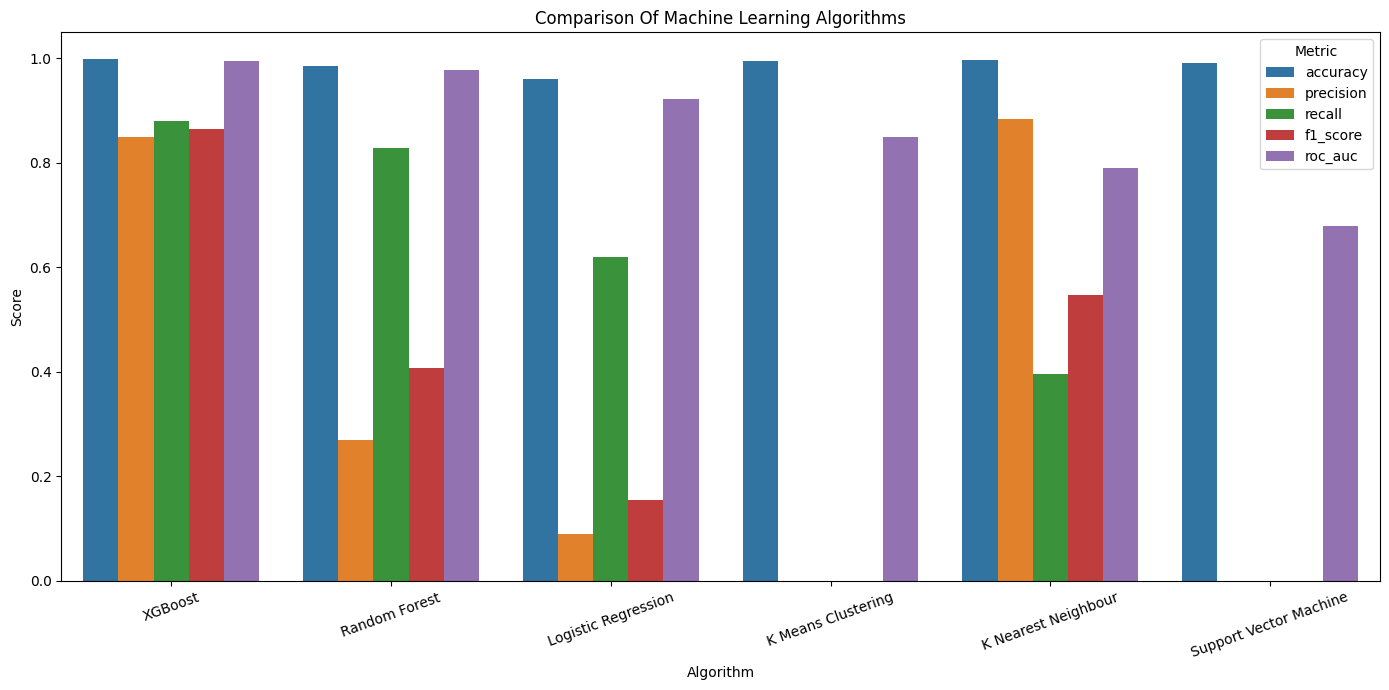

In [ ]:
# Plot Comparison Metrics
plot_df = comparison_df.melt(
    id_vars="model",
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Comparison Of Machine Learning Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


In [ ]:
# Train The Final XGBoost Fraud Detection Model
fraud_count = max(int(y_train.sum()), 1)
normal_count = max(int((y_train == 0).sum()), 1)
scale_pos_weight = normal_count / fraud_count

model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=4,
)

model.fit(X_train_processed, y_train)
print("Model training completed.")


Model training completed.


In [ ]:
# Evaluate Final Model Performance
y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1]

metrics = {
    "dataset": TRAIN_DATA_PATH.name,
    "trained_at": datetime.now().isoformat(),
    "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
    "roc_auc": round(float(roc_auc_score(y_test, y_prob)), 4),
    "report": classification_report(y_test, y_pred, output_dict=True),
}

print("Accuracy:", metrics["accuracy"])
print("ROC-AUC:", metrics["roc_auc"])
print(json.dumps(metrics["report"], indent=2))


Accuracy: 0.9906
ROC-AUC: 0.9989
{
  "0": {
    "precision": 0.9998356106477332,
    "recall": 0.9907498623145125,
    "f1-score": 0.9952720011688502,
    "support": 257834.0
  },
  "1": {
    "precision": 0.3795525494276795,
    "recall": 0.972018654230513,
    "f1-score": 0.5459307764265668,
    "support": 1501.0
  },
  "accuracy": 0.9906414483197409,
  "macro avg": {
    "precision": 0.6896940800377064,
    "recall": 0.9813842582725127,
    "f1-score": 0.7706013887977086,
    "support": 259335.0
  },
  "weighted avg": {
    "precision": 0.9962454863880255,
    "recall": 0.9906414483197409,
    "f1-score": 0.9926712678380688,
    "support": 259335.0
  }
}


In [ ]:
# Save Model And Preprocessing Artifacts
artifacts = {
    "preprocessor": preprocessor,
    "feature_columns": FEATURE_COLUMNS,
    "model_version": "xgboost-kartik-v1",
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

joblib.dump(model, MODEL_PATH)
joblib.dump(artifacts, ENCODERS_PATH)
METRICS_PATH.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print("Model saved to:", MODEL_PATH)
print("Artifacts saved to:", ENCODERS_PATH)
print("Metrics saved to:", METRICS_PATH)
print("Comparison metrics saved to:", ALGORITHM_COMPARISON_PATH)


Model saved to: fraud_model.pkl
Artifacts saved to: encoders.pkl
Metrics saved to: training_metrics.json
Comparison metrics saved to: algorithm_comparison_metrics.json


In [ ]:
# Load Raw Test Dataset
test_df_raw = pd.read_csv(TEST_DATA_PATH)

print("Test dataset loaded from:", TEST_DATA_PATH)
print("Test dataset shape:", test_df_raw.shape)
test_df_raw.head()


Test dataset loaded from: fraudTest.csv
Test dataset shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [ ]:
# Preprocess Test Dataset
test_df_raw["trans_date_trans_time"] = pd.to_datetime(
    test_df_raw["trans_date_trans_time"], errors="coerce"
)
test_df_raw["dob"] = pd.to_datetime(test_df_raw["dob"], errors="coerce")

age_days = (test_df_raw["trans_date_trans_time"] - test_df_raw["dob"]).dt.days
test_df_raw["age"] = (age_days / 365.25).clip(lower=0)
test_df_raw["hour"] = test_df_raw["trans_date_trans_time"].dt.hour
test_df_raw["distance_km"] = haversine_distance(
    test_df_raw["lat"],
    test_df_raw["long"],
    test_df_raw["merch_lat"],
    test_df_raw["merch_long"],
)

test_df = test_df_raw[FEATURE_COLUMNS + ["is_fraud"]].dropna(subset=["is_fraud"]).copy()
print("Prepared test dataset shape:", test_df.shape)


Prepared test dataset shape: (555719, 11)


In [ ]:
# Test Saved Model On fraudTest.csv
saved_model = joblib.load(MODEL_PATH)
saved_artifacts = joblib.load(ENCODERS_PATH)
saved_preprocessor = saved_artifacts["preprocessor"]

X_test_final = test_df[FEATURE_COLUMNS]
y_test_final = test_df["is_fraud"].astype(int)

X_test_final_processed = saved_preprocessor.transform(X_test_final)
y_test_final_pred = saved_model.predict(X_test_final_processed)
y_test_final_prob = saved_model.predict_proba(X_test_final_processed)[:, 1]

test_metrics = calculate_metrics(
    "Saved XGBoost Model",
    y_test_final,
    y_test_final_pred,
    y_test_final_prob,
)
test_metrics["dataset"] = TEST_DATA_PATH.name
test_metrics["evaluated_at"] = datetime.now().isoformat()

test_metrics


{'model': 'Saved XGBoost Model',
 'accuracy': 0.9906,
 'precision': 0.2828,
 'recall': 0.9357,
 'f1_score': 0.4344,
 'roc_auc': 0.9963,
 'report': {'0': {'precision': 0.9997484611472723,
   'recall': 0.9908070104448548,
   'f1-score': 0.9952576535773551,
   'support': 553574.0},
  '1': {'precision': 0.28283540022547915,
   'recall': 0.9356643356643357,
   'f1-score': 0.4343685748295639,
   'support': 2145.0},
  'accuracy': 0.9905941671960109,
  'macro avg': {'precision': 0.6412919306863758,
   'recall': 0.9632356730545952,
   'f1-score': 0.7148131142034595,
   'support': 555719.0},
  'weighted avg': {'precision': 0.996981273925534,
   'recall': 0.9905941671960109,
   'f1-score': 0.993092697774307,
   'support': 555719.0}},
 'dataset': 'fraudTest.csv',
 'evaluated_at': '2026-04-09T19:37:00.015304'}

In [ ]:
# Save Test Metrics
TEST_METRICS_PATH.write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
print("Test metrics saved to:", TEST_METRICS_PATH)


Test metrics saved to: test_metrics.json


In [ ]:
# Download Output Files
files.download("fraud_model.pkl")
files.download("encoders.pkl")
files.download("training_metrics.json")
files.download("algorithm_comparison_metrics.json")
files.download("test_metrics.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>